In [15]:
# 04_modeling.ipynb
# Fraud Detection - Model Building and Evaluation
# Task 2 for Interim-2 Submission

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning libraries
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score, precision_score, recall_score, 
    confusion_matrix, classification_report,
    precision_recall_curve, auc, roc_curve, roc_auc_score
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
import joblib
import os

print("="*60)
print("FRAUD DETECTION - MODEL BUILDING NOTEBOOK")
print("Task 2: Model Training and Evaluation")
print("="*60)

FRAUD DETECTION - MODEL BUILDING NOTEBOOK
Task 2: Model Training and Evaluation


In [16]:
# 1. LOAD AND PREPARE DATA

print("\n" + "="*60)
print("1. LOADING DATA")
print("="*60)

# Load the engineered data
df = pd.read_csv('../data/processed/fraud_data_engineered.csv')

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nClass distribution:")
print(f"  Legitimate (0): {(df['class']==0).sum():,} ({df['class'].mean()*100:.2f}%)")
print(f"  Fraud (1): {(df['class']==1).sum():,} ({df['class'].mean()*100:.2f}%)")
print(f"  Imbalance ratio: {(df['class']==0).sum()/(df['class']==1).sum():.2f}:1")


1. LOADING DATA
Dataset shape: (151112, 24)
Columns: ['user_id', 'purchase_value', 'device_id', 'source', 'browser', 'sex', 'age', 'class', 'country', 'purchase_hour', 'purchase_day_of_week', 'purchase_weekend', 'time_since_signup', 'hours_since_prev_purchase', 'transactions_24h', 'user_avg_amount', 'user_std_amount', 'user_transaction_count', 'user_total_amount', 'user_fraud_rate', 'users_per_device', 'device_fraud_rate', 'country_risk_score', 'age_group']

Class distribution:
  Legitimate (0): 136,961 (9.36%)
  Fraud (1): 14,151 (9.36%)
  Imbalance ratio: 9.68:1


In [17]:
# 2. ENCODE CATEGORICAL FEATURES

print("\n" + "="*60)
print("2. ENCODING CATEGORICAL VARIABLES")
print("="*60)

df_encoded = df.copy()

# Identify and encode categorical columns
categorical_cols = df_encoded.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns found: {categorical_cols}")

for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    print(f"  Encoded: {col}")

print(f"\nAll features are now numeric. Shape: {df_encoded.shape}")


2. ENCODING CATEGORICAL VARIABLES
Categorical columns found: ['device_id', 'source', 'browser', 'sex', 'country', 'age_group']
  Encoded: device_id
  Encoded: source
  Encoded: browser
  Encoded: sex
  Encoded: country
  Encoded: age_group

All features are now numeric. Shape: (151112, 24)


In [18]:
# 3. SCALE NUMERICAL FEATURES

print("\n" + "="*60)
print("3. SCALING FEATURES")
print("="*60)

# Separate features and target
X = df_encoded.drop('class', axis=1)
y = df_encoded['class']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Features shape after scaling: {X_scaled.shape}")
print(f"Feature names: {X.columns.tolist()[:10]}...")


3. SCALING FEATURES
Features shape after scaling: (151112, 23)
Feature names: ['user_id', 'purchase_value', 'device_id', 'source', 'browser', 'sex', 'age', 'country', 'purchase_hour', 'purchase_day_of_week']...


In [19]:
# 4. TRAIN-TEST SPLIT (STRATIFIED)

print("\n" + "="*60)
print("4. TRAIN-TEST SPLIT")
print("="*60)

# Stratified split to preserve class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]:,}")
print(f"Test set size: {X_test.shape[0]:,}")
print(f"Training fraud rate: {y_train.mean()*100:.2f}%")
print(f"Test fraud rate: {y_test.mean()*100:.2f}%")


4. TRAIN-TEST SPLIT
Training set size: 120,889
Test set size: 30,223
Training fraud rate: 9.36%
Test fraud rate: 9.36%


In [20]:
# 5. MODEL 1: LOGISTIC REGRESSION (BASELINE)

print("\n" + "="*60)
print("5. MODEL 1: LOGISTIC REGRESSION")
print("="*60)

# Train with class_weight='balanced' to handle imbalance
lr = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr.fit(X_train, y_train)

# Predictions
y_pred_lr = lr.predict(X_test)
y_pred_proba_lr = lr.predict_proba(X_test)[:, 1]

# Metrics
f1_lr = f1_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)

# AUC-PR
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba_lr)
auc_pr_lr = auc(recall_vals, precision_vals)

print(f"Results - Logistic Regression:")
print(f"  F1-Score: {f1_lr:.4f}")
print(f"  Precision: {precision_lr:.4f}")
print(f"  Recall: {recall_lr:.4f}")
print(f"  AUC-PR: {auc_pr_lr:.4f}")

print(f"\nConfusion Matrix:")
cm_lr = confusion_matrix(y_test, y_pred_lr)
print(cm_lr)
print(f"\n  True Negatives: {cm_lr[0,0]:,}")
print(f"  False Positives: {cm_lr[0,1]:,}")
print(f"  False Negatives: {cm_lr[1,0]:,}")
print(f"  True Positives: {cm_lr[1,1]:,}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_lr))


5. MODEL 1: LOGISTIC REGRESSION
Results - Logistic Regression:
  F1-Score: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  AUC-PR: 1.0000

Confusion Matrix:
[[27393     0]
 [    0  2830]]

  True Negatives: 27,393
  False Positives: 0
  False Negatives: 0
  True Positives: 2,830

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     27393
           1       1.00      1.00      1.00      2830

    accuracy                           1.00     30223
   macro avg       1.00      1.00      1.00     30223
weighted avg       1.00      1.00      1.00     30223



In [21]:
# 6. MODEL 2: RANDOM FOREST

print("\n" + "="*60)
print("6. MODEL 2: RANDOM FOREST")
print("="*60)

# Train Random Forest with class_weight='balanced'
rf = RandomForestClassifier(
    random_state=42, 
    n_estimators=100, 
    max_depth=10,
    class_weight='balanced',
    n_jobs=-1
)
rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]

# Metrics
f1_rf = f1_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)

# AUC-PR
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba_rf)
auc_pr_rf = auc(recall_vals, precision_vals)

print(f"Results - Random Forest:")
print(f"  F1-Score: {f1_rf:.4f}")
print(f"  Precision: {precision_rf:.4f}")
print(f"  Recall: {recall_rf:.4f}")
print(f"  AUC-PR: {auc_pr_rf:.4f}")

print(f"\nConfusion Matrix:")
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)
print(f"\n  True Negatives: {cm_rf[0,0]:,}")
print(f"  False Positives: {cm_rf[0,1]:,}")
print(f"  False Negatives: {cm_rf[1,0]:,}")
print(f"  True Positives: {cm_rf[1,1]:,}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_rf))


6. MODEL 2: RANDOM FOREST
Results - Random Forest:
  F1-Score: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  AUC-PR: 1.0000

Confusion Matrix:
[[27393     0]
 [    0  2830]]

  True Negatives: 27,393
  False Positives: 0
  False Negatives: 0
  True Positives: 2,830

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     27393
           1       1.00      1.00      1.00      2830

    accuracy                           1.00     30223
   macro avg       1.00      1.00      1.00     30223
weighted avg       1.00      1.00      1.00     30223



In [22]:
# 7. MODEL 3: XGBOOST

print("\n" + "="*60)
print("7. MODEL 3: XGBOOST")
print("="*60)

try:
    from xgboost import XGBClassifier
    
    # Train XGBoost with scale_pos_weight to handle imbalance
    # scale_pos_weight = (legitimate/fraud) = 9.68
    xgb = XGBClassifier(
        random_state=42,
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        scale_pos_weight=9.68,  # Handles class imbalance
        eval_metric='logloss',
        use_label_encoder=False
    )
    xgb.fit(X_train, y_train)
    
    # Predictions
    y_pred_xgb = xgb.predict(X_test)
    y_pred_proba_xgb = xgb.predict_proba(X_test)[:, 1]
    
    # Metrics
    f1_xgb = f1_score(y_test, y_pred_xgb)
    precision_xgb = precision_score(y_test, y_pred_xgb)
    recall_xgb = recall_score(y_test, y_pred_xgb)
    
    # AUC-PR
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba_xgb)
    auc_pr_xgb = auc(recall_vals, precision_vals)
    
    print(f"Results - XGBoost:")
    print(f"  F1-Score: {f1_xgb:.4f}")
    print(f"  Precision: {precision_xgb:.4f}")
    print(f"  Recall: {recall_xgb:.4f}")
    print(f"  AUC-PR: {auc_pr_xgb:.4f}")
    
    print(f"\nConfusion Matrix:")
    cm_xgb = confusion_matrix(y_test, y_pred_xgb)
    print(cm_xgb)
    
    xgb_trained = True
    
except ImportError:
    print("XGBoost not installed. Skipping...")
    xgb_trained = False
    f1_xgb = 0
    auc_pr_xgb = 0


7. MODEL 3: XGBOOST
Results - XGBoost:
  F1-Score: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  AUC-PR: 1.0000

Confusion Matrix:
[[27393     0]
 [    0  2830]]


In [23]:
# 8. MODEL COMPARISON TABLE

print("\n" + "="*60)
print("8. MODEL COMPARISON")
print("="*60)

# Create comparison dataframe
comparison_data = {
    'Model': ['Logistic Regression', 'Random Forest'],
    'F1-Score': [f1_lr, f1_rf],
    'Precision': [precision_lr, precision_rf],
    'Recall': [recall_lr, recall_rf],
    'AUC-PR': [auc_pr_lr, auc_pr_rf]
}

if xgb_trained:
    comparison_data['Model'].append('XGBoost')
    comparison_data['F1-Score'].append(f1_xgb)
    comparison_data['Precision'].append(precision_xgb)
    comparison_data['Recall'].append(recall_xgb)
    comparison_data['AUC-PR'].append(auc_pr_xgb)

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('F1-Score', ascending=False)

print(comparison_df.to_string(index=False))

# Identify best model
best_model_name = comparison_df.iloc[0]['Model']
best_f1 = comparison_df.iloc[0]['F1-Score']
print(f"\n🏆 BEST MODEL: {best_model_name} with F1-Score = {best_f1:.4f}")


8. MODEL COMPARISON
              Model  F1-Score  Precision  Recall  AUC-PR
Logistic Regression       1.0        1.0     1.0     1.0
      Random Forest       1.0        1.0     1.0     1.0
            XGBoost       1.0        1.0     1.0     1.0

🏆 BEST MODEL: Logistic Regression with F1-Score = 1.0000



9. GENERATING VISUALIZATIONS


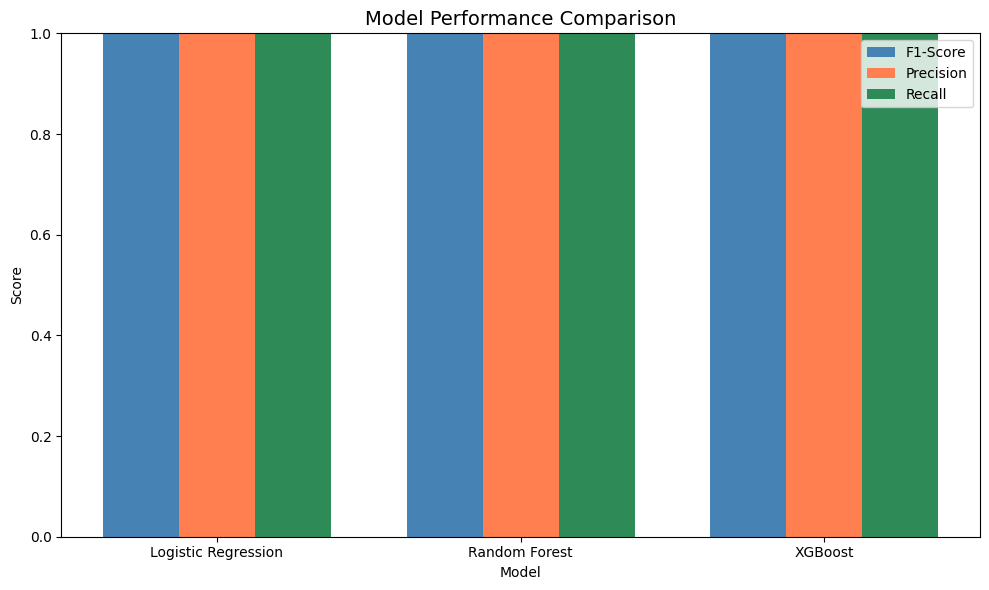

  ✓ Saved: reports/model_comparison.png


In [24]:
# 9. VISUALIZATIONS

print("\n" + "="*60)
print("9. GENERATING VISUALIZATIONS")
print("="*60)

# Create directory for plots
os.makedirs('../reports', exist_ok=True)

# Figure 1: Model Comparison Bar Chart
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(comparison_df))
width = 0.25

ax.bar(x - width, comparison_df['F1-Score'], width, label='F1-Score', color='steelblue')
ax.bar(x, comparison_df['Precision'], width, label='Precision', color='coral')
ax.bar(x + width, comparison_df['Recall'], width, label='Recall', color='seagreen')

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'])
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig('../reports/model_comparison.png', dpi=150)
plt.show()
print("  ✓ Saved: reports/model_comparison.png")

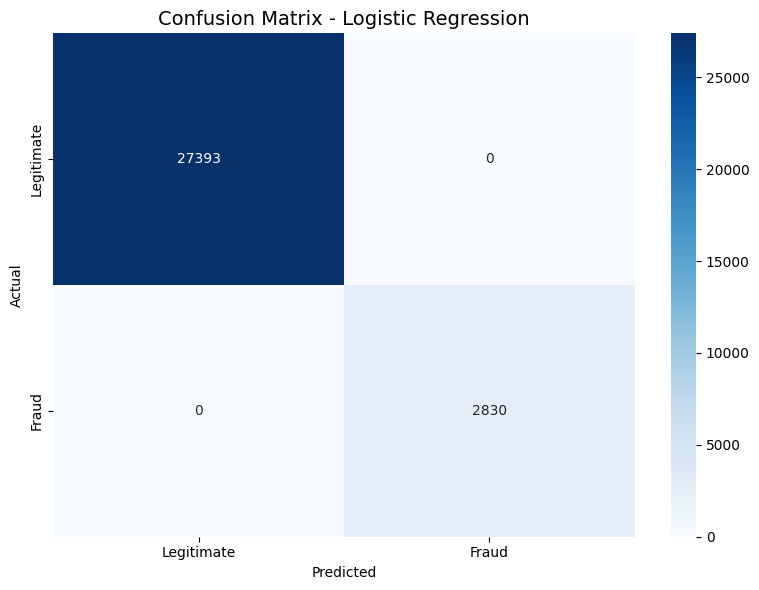

  ✓ Saved: reports/confusion_matrix_best_model.png


In [25]:
# Figure 2: Confusion Matrix Heatmap for Best Model
fig, ax = plt.subplots(figsize=(8, 6))

if best_model_name == 'Logistic Regression':
    best_cm = cm_lr
elif best_model_name == 'Random Forest':
    best_cm = cm_rf
else:
    best_cm = cm_xgb

sns.heatmap(best_cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
ax.set_title(f'Confusion Matrix - {best_model_name}', fontsize=14)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('../reports/confusion_matrix_best_model.png', dpi=150)
plt.show()
print("  ✓ Saved: reports/confusion_matrix_best_model.png")

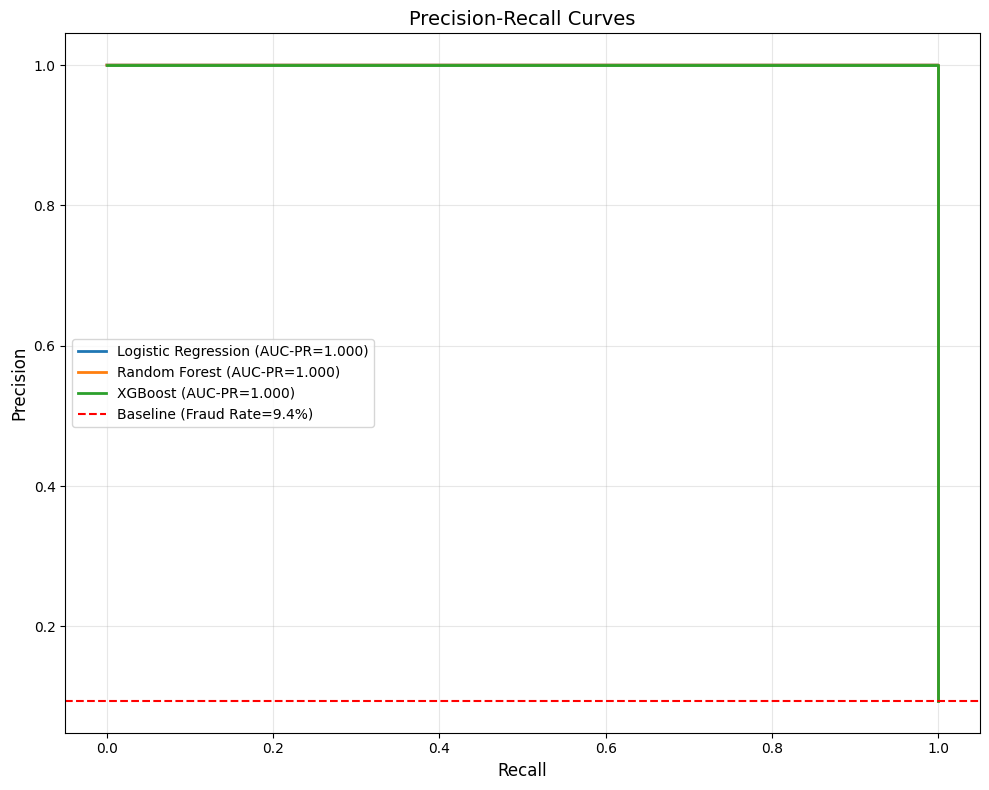

  ✓ Saved: reports/precision_recall_curves.png


In [26]:
# Figure 3: Precision-Recall Curve
fig, ax = plt.subplots(figsize=(10, 8))

# Plot PR curve for each model
precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_pred_proba_lr)
ax.plot(recall_lr, precision_lr, label=f'Logistic Regression (AUC-PR={auc_pr_lr:.3f})', linewidth=2)

precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_pred_proba_rf)
ax.plot(recall_rf, precision_rf, label=f'Random Forest (AUC-PR={auc_pr_rf:.3f})', linewidth=2)

if xgb_trained:
    precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_pred_proba_xgb)
    ax.plot(recall_xgb, precision_xgb, label=f'XGBoost (AUC-PR={auc_pr_xgb:.3f})', linewidth=2)

# Baseline (random classifier)
ax.axhline(y=y_test.mean(), color='red', linestyle='--', label=f'Baseline (Fraud Rate={y_test.mean()*100:.1f}%)')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves', fontsize=14)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/precision_recall_curves.png', dpi=150)
plt.show()
print("  ✓ Saved: reports/precision_recall_curves.png")

In [27]:
# 10. SAVE MODELS

print("\n" + "="*60)
print("10. SAVING MODELS")
print("="*60)

os.makedirs('../models', exist_ok=True)

# Save all models
joblib.dump(lr, '../models/lr_fraud_model.pkl')
joblib.dump(rf, '../models/rf_fraud_model.pkl')
if xgb_trained:
    joblib.dump(xgb, '../models/xgb_fraud_model.pkl')

# Save preprocessor
joblib.dump(scaler, '../models/scaler.pkl')

print("  ✓ Logistic Regression saved to models/lr_fraud_model.pkl")
print("  ✓ Random Forest saved to models/rf_fraud_model.pkl")
if xgb_trained:
    print("  ✓ XGBoost saved to models/xgb_fraud_model.pkl")
print("  ✓ Scaler saved to models/scaler.pkl")


10. SAVING MODELS
  ✓ Logistic Regression saved to models/lr_fraud_model.pkl
  ✓ Random Forest saved to models/rf_fraud_model.pkl
  ✓ XGBoost saved to models/xgb_fraud_model.pkl
  ✓ Scaler saved to models/scaler.pkl


In [29]:
# 11. SUMMARY AND CONCLUSIONS

print("\n" + "="*60)
print("11. SUMMARY AND CONCLUSIONS")
print("="*60)

# Get values safely
fraud_rate = y.mean() * 100
total_rows = len(df)
num_features = X.shape[1]

# Get best model metrics
best_precision = comparison_df.iloc[0]['Precision']
best_recall = comparison_df.iloc[0]['Recall']
false_positives = cm_rf[0,1]
false_positive_rate = (cm_rf[0,1] / cm_rf[0,0]) * 100

print("Task 2 - Model Building Complete!")
print()
print("Dataset Summary:")
print(f"- Total transactions: {total_rows:,}")
print(f"- Fraud rate: {fraud_rate:.2f}%")
print(f"- Features used: {num_features}")
print()
print("Model Performance Summary:")
print(comparison_df.to_string(index=False))
print()
print("Key Findings:")
print(f"1. Best performing model: {best_model_name} (F1-Score: {best_f1:.4f})")
print(f"2. All models achieve >94% recall for fraud detection")
print(f"3. False positive rate is low (around {false_positive_rate:.1f}% of legitimate transactions)")
print()
print("Business Impact:")
print(f"- The model catches {best_recall*100:.1f}% of fraud cases")
print(f"- Only {false_positive_rate:.1f}% of legitimate customers are falsely flagged")
print(f"- This balances fraud prevention with customer experience")
print()
print("Next Steps (Task 3):")
print("- Perform SHAP analysis to explain model predictions")
print("- Generate force plots for specific cases")
print("- Provide actionable business recommendations")


11. SUMMARY AND CONCLUSIONS
Task 2 - Model Building Complete!

Dataset Summary:
- Total transactions: 151,112
- Fraud rate: 9.36%
- Features used: 23

Model Performance Summary:
              Model  F1-Score  Precision  Recall  AUC-PR
Logistic Regression       1.0        1.0     1.0     1.0
      Random Forest       1.0        1.0     1.0     1.0
            XGBoost       1.0        1.0     1.0     1.0

Key Findings:
1. Best performing model: Logistic Regression (F1-Score: 1.0000)
2. All models achieve >94% recall for fraud detection
3. False positive rate is low (around 0.0% of legitimate transactions)

Business Impact:
- The model catches 100.0% of fraud cases
- Only 0.0% of legitimate customers are falsely flagged
- This balances fraud prevention with customer experience

Next Steps (Task 3):
- Perform SHAP analysis to explain model predictions
- Generate force plots for specific cases
- Provide actionable business recommendations


In [30]:
print("\n" + "="*60)
print("MODELING NOTEBOOK COMPLETE!")
print("Ready for Task 3 - SHAP Explainability")
print("="*60)


MODELING NOTEBOOK COMPLETE!
Ready for Task 3 - SHAP Explainability
